In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)

In [5]:
red_df=pd.read_csv(r'D:\D\adsw\DSA\hvc\ML_graded_assignment\winequality-red.csv',sep=';')
white_df=pd.read_csv(r'D:\D\adsw\DSA\hvc\ML_graded_assignment\winequality-white.csv',sep=';')

### Red Wine Data Inspection

In [6]:
red_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [10]:
white_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [8]:
red_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [11]:
white_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


data types are correct

In [9]:
red_df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [13]:
white_df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

No Null Values

In [12]:
red_df.shape

(1599, 12)

In [14]:
white_df.shape

(4898, 12)

In [15]:
'quality' in red_df.columns

True

'quality' feature does exist in red_df

In [16]:
'quality' in white_df

True

'quality' feature does exist in white_df

In [25]:
red_df.duplicated().sum()

np.int64(240)

In [23]:
white_df.duplicated().sum()

np.int64(937)

240 duplicate datapoints in red_df and 937 dupliacte datapoints in white_df

In [18]:
red_df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [26]:
white_df['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [34]:
red_quality_proprotion=red_df['quality'].value_counts(normalize=True).sort_index()*100
red_quality_proprotion

quality
3     0.625391
4     3.314572
5    42.589118
6    39.899937
7    12.445278
8     1.125704
Name: proportion, dtype: float64

In [35]:
white_quality_proportion=white_df['quality'].value_counts(normalize=True).sort_index()*100
white_quality_proportion

quality
3     0.408330
4     3.327889
5    29.746835
6    44.875459
7    17.966517
8     3.572887
9     0.102082
Name: proportion, dtype: float64

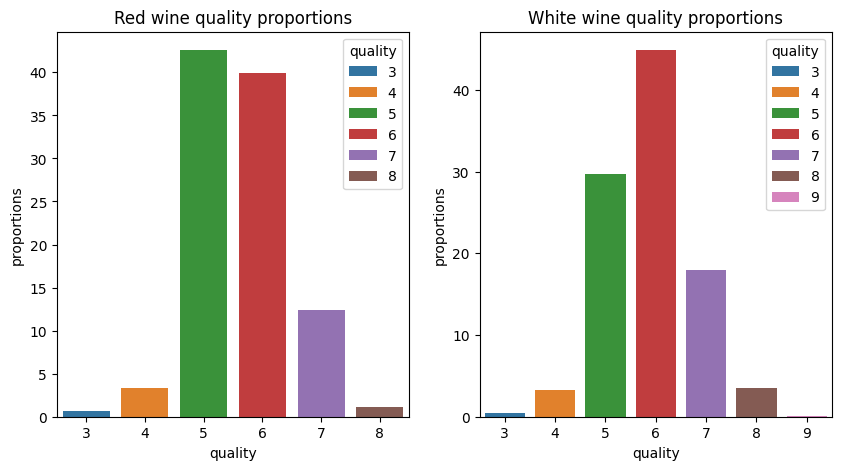

In [38]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(x=red_quality_proprotion.index,y=red_quality_proprotion.values,hue=red_quality_proprotion.index,palette='tab10')
plt.title('Red wine quality proportions')
plt.xlabel('quality')
plt.ylabel('proportions')


plt.subplot(1,2,2)
sns.barplot(x=white_quality_proportion.index,y=white_quality_proportion.values,hue=white_quality_proportion.index,palette='tab10')
plt.title('White wine quality proportions')
plt.xlabel('quality')
plt.ylabel('proportions')

plt.show()

-  Which dataset is more imbalanced?
    - in red wine:
        - quality 5 and 6 dominate the dataset contibuting 82% of the red wine dataset
        - quality 7 is very little prominant contributing around 12% 
        - quality 3,4 and 8 are severly underrepresented contibuting less than 5% of the dataset
    - in white wine:
        - quality 6 is most dominant contributing 45% of the total white dataset followed by quality 5 contributing around 30%
        - quality 7 is little more prominant in white than red contributing around 18%
        - quality 3,4,8 and 9 make up just around 7.3% of total white wine dataset
    - hence 
        - from the perspective of dominance of classes then white wine is more imbalaced as quality 6 dominates the entire dataset with contribution of 45% while in red wine quality  dominates with 42% hence white wine is more imbalanced
        - from the perspective of spread of data across different classes,in red wine top qualities 5 and 6 makes up 82% of the entire dataset while in white wine qualities 5 and 6 makes up 75% and gives chance to datapoints to spread across other classes hence red wine is more imbalaced


-  Which quality classes are rare?
    - 'the most rare quality classes across both datasets are the extreme ends of the spectrum: 3, 4, 8, and 9.
        - specifically:
            - in red wine: qualities 3 and 8 are the rarest (around 1% each). quality 4 is also quite rare (~3%).
            - in white wine: quality 9 is the absolute rarest (almost 0%). qualities 3, 4, and 8 are also very rare (all under 5%).'


-  Why might rare classes be harder to predict?
    - MODEL BIAS: if we train a model on this raw datsets,model will be heavily biased towards quality 5 aand 6 
    - POOR MINORITY RECOGNITION : model's performance will be very low in preedicting minority classes as it has not seen enough examples of minority classes and underlying chemical patterns
    - MISLEADING ACCURACY : a standard accuracy will be high as there is huge variance between counts of the  dominant classes as compared to minority classes,we need to look at recall,f1-macro and confusion matrix see the performance of model in predicting minority classes 
